# Where the family speaks and ESM-2 does not

`README.md` reports, for the 28 EGFP window positions, that the family MSA and the ESM-2 650M
masked marginal are close to orthogonal. This notebook takes that finding out of the window and
makes it the subject: **the two distributions this project can put on a residue position — the
one the FP family supplies, and the one the protein language model supplies — are not two noisy
views of the same thing.** Over the whole barrel they disagree about *where* a position is
constrained, they disagree most at exactly the positions the family holds hardest, and only one
of them predicts the residue a real FP actually carries.

Both objects are distributions over the same 20 letters at the same position, so every panel
below is a direct comparison:

* **MSA profile.** The Henikoff-weighted column frequency from the 763-sequence alignment
  (`results/column_conservation.csv`), N_eff = 272. This is the object `window_alphabet_egfp.csv`
  is derived from.
* **ESM-2.** The masked marginal produced exactly as `fpdesign/campaign.py` produces it
  (`esm_logits_at`): mask the position in the unmodified sequence, restrict the logits to the 20
  standard amino acids, softmax. This is literally the distribution the design search samples its
  top-*k* from. It is taken on the **EGFP scaffold** throughout — the sequence the campaign
  actually edits — and reported in avGFP numbering like everything else here.

Analysis is restricted throughout to the **208 near-complete columns** (occupancy ≥ 90%), the same
set every other analysis in this folder uses, and structural annotation (RSA, chromophore distance)
comes from 1GFL in avGFP numbering.

Figures follow the **2026 Arcadia style guide**, matching
[`../dataset_pipeline/visualize_curation.ipynb`](../dataset_pipeline/visualize_curation.ipynb).

> Run from `msa_conservation/`. Prerequisites, in order: the pipeline in `README.md` through
> `python conservation.py`, then **`python esm_profiles.py`** (needs a GPU, ~9 min) which caches
> every ESM-2 distribution used here into `results/esm_profiles.npz`,
> `results/esm_sweep_profiles.npz` and `results/esm_family_sweep.csv`. Nothing below needs a GPU.

In [1]:
# The inline backend crops to "tight" by default, which silently rescales every figure and
# throws away the guide's panel dimensions. Turn it off so a 1000px panel really is 1000px.
%config InlineBackend.print_figure_kwargs = {"bbox_inches": None}

import json
import os
import sys

# Everything here is relative to msa_conservation/: results/*.csv, the figures/ output directory,
# and conservation.py, imported below for the leave-one-out profile. A kernel started at the
# repository root -- VS Code's default when the workspace root is the repo -- would miss all three.
if os.path.basename(os.getcwd()) != "msa_conservation":
    if os.path.isdir("msa_conservation"):
        os.chdir("msa_conservation")
    else:
        raise RuntimeError(f"run this notebook from msa_conservation/; cwd is {os.getcwd()}")

try:
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    from scipy.stats import spearmanr

    import arcadia_pycolor as apc
except ModuleNotFoundError as e:      # a stray kernel is the usual cause, not a broken install
    raise ModuleNotFoundError(
        f"{e.name} not found. Select the `spectrum-to-fp-design` kernel -- the conda env of that name is "
        "where this repo's dependencies live, and the sibling notebooks use it too.") from e

sys.path.insert(0, ".")
import conservation as cv          # load_alignment / encode / henikoff_weights, reused for LOO

FONTS = "../dataset_pipeline/fonts"
apc.mpl.setup(font_dirpath=FONTS if os.path.isdir(FONTS) else None)
if not os.path.isdir(FONTS):
    print("NOTE: run `python fetch_arcadia_fonts.py` in dataset_pipeline/ for the Atkinson faces")

# apc pins figure.dpi to 72 so one point equals one style-guide pixel. Keep that for layout, but
# render at 2x so the inline PNGs are not soft on screen.
plt.rcParams["figure.dpi"] = 144

FIGDIR = "figures"
os.makedirs(FIGDIR, exist_ok=True)
AAS = "ACDEFGHIKLMNPQRSTVWY"
print(f"python {sys.version.split()[0]} | {os.getcwd()} | figures -> {FIGDIR}/")

python 3.10.20 | /home/ubuntu/spectrum-to-fp-design/msa_conservation | figures -> figures/


### Style-guide helpers

The same constants the sibling notebooks use — panel geometry in the guide's pixels (Full_wide
1000, Float 650), and since `arcadia_pycolor` pins the figure DPI to 72, one matplotlib point is
exactly one style-guide pixel.

One colour decision holds across every figure below, so it is made once here: **the MSA profile
is aegean and ESM-2 is amber, everywhere.** The whole notebook is one comparison between those two
distributions, so nothing else is allowed to take those two colours. Control proteins — the
ordinary, non-FP sequences that calibrate what a *sharp* language model looks like — are
asparagus, and structural or contextual material is neutral.

In [2]:
PX = 1 / 72                       # one style-guide pixel, expressed in inches
FULL_WIDE, FLOAT, HALF_SQUARE = 1000, 650, 490

# Text roles, straight from the guide's "Text styles" page
PANEL_LETTER = dict(fontsize=38, fontweight="regular", color=str(apc.chateau))
ANNOTATION = dict(fontsize=15, fontweight="ultralight", color=str(apc.charcoal))
NUMBER_NOTE = dict(fontfamily="Atkinson Hyperlegible Mono", fontsize=14.5, color=str(apc.charcoal))

HIGHLIGHT, CONTRAST = str(apc.aegean), str(apc.amber)
NEUTRAL, NEUTRAL_SOFT = str(apc.chateau), str(apc.taupe)

C_FAM = HIGHLIGHT                 # the MSA profile: family column distribution
C_ESM = CONTRAST                  # the ESM-2 650M masked marginal
C_CTRL = str(apc.asparagus)       # ordinary (non-FP) control proteins
C_POCKET = str(apc.canary)        # 5 A chromophore shell, shading only

MAXH = np.log2(20)                # 4.32 bits: a flat distribution over the 20 residues


def panel_letter(ax, letter, dx=-46, dy=12):
    ax.annotate(letter, xy=(0, 1), xycoords="axes fraction", xytext=(dx, dy),
                textcoords="offset points", ha="left", va="bottom",
                annotation_clip=False, **PANEL_LETTER)


def finish(ax, mono="both"):
    """apc.mpl.style_plot with the numeral font applied to `mono` ("both", "x", "y" or None).

    style_plot runs the buggy style_legend on any legend already attached (its title rule assumes
    dpi 72 and draws the rule ~2x too wide at this notebook's 144), so every panel here styles the
    axes FIRST and adds its legend afterwards.
    """
    apc.mpl.style_plot(ax, monospaced_axes=mono)


def style_key(leg):
    apc.mpl.capitalize_legend_text(leg)
    apc.mpl.justify_legend_text(leg)
    return leg


def save(fig, name):
    fig.savefig(f"{FIGDIR}/{name}.svg")
    fig.savefig(f"{FIGDIR}/{name}.png", dpi=300)

## 0. The two distributions, on one index

Everything below is built from three objects, joined on avGFP position:

| object | shape | source |
|---|---|---|
| `F` — family column frequencies | (208, 20) | `results/column_conservation.csv`, Henikoff-weighted |
| `E` — ESM-2 masked marginals on EGFP | (208, 20) | `results/esm_profiles.npz` |
| `col` — structural context | (208, ·) | 1GFL: RSA, chromophore distance, secondary structure |

Two scalars summarise each distribution at a position: its **entropy** in bits (0 = one residue
always, 4.32 = flat over 20), and their **Jensen–Shannon divergence** (0 = identical, 1 bit =
disjoint support). Neither depends on which of the two is "right".

In [3]:
def entropy_bits(P, axis=-1, eps=1e-12):
    P = np.asarray(P, dtype=float)
    return -(P * np.log2(P + eps)).sum(axis=axis)


def js_bits(P, Q, eps=1e-12):
    """Row-wise Jensen-Shannon divergence in bits."""
    P, Q = np.atleast_2d(P) + eps, np.atleast_2d(Q) + eps
    P, Q = P / P.sum(1, keepdims=True), Q / Q.sum(1, keepdims=True)
    M = 0.5 * (P + Q)
    kl = lambda X, Y: (X * np.log2(X / Y)).sum(1)
    return 0.5 * kl(P, M) + 0.5 * kl(Q, M)


cons = pd.read_csv("results/column_conservation.csv")
col = cons[(cons.occupancy >= 0.90) & (cons.ref_pos > 0)].sort_values("ref_pos").reset_index(drop=True)
summary = json.load(open("results/summary.json"))

prof = dict(np.load("results/esm_profiles.npz"))
pmeta = json.load(open("results/esm_profiles_meta.json"))

F = col[[f"f_aa_{a}" for a in AAS]].to_numpy()                 # family, per column

# ESM-2 is taken on EGFP, the scaffold the campaign actually edits. EGFP carries an extra Val
# after Met1 and no other indel, so avGFP position p is EGFP position p + 1 for p >= 2 while Met1
# maps to Met1 -- as a 0-based index into the EGFP profile, p everywhere except p = 1.
egfp_seq, avgfp_seq = pmeta["sequences"]["EGFP"], pmeta["sequences"]["avGFP"]
assert len(egfp_seq) == len(avgfp_seq) + 1
esm_idx = np.where(col.ref_pos.to_numpy() == 1, 0, col.ref_pos.to_numpy()).astype(int)
E = prof["EGFP"][esm_idx]                                      # ESM-2, same positions
col["esm_aa"] = [egfp_seq[i] for i in esm_idx]
# the only core columns where the scaffold letter differs from avGFP are EGFP's own substitutions
# (H231L falls outside the 208 columns)
diff = [(int(p), a, b) for p, a, b in zip(col.ref_pos, col.ref_aa, col.esm_aa) if a != b]
assert diff == [(64, "F", "L"), (65, "S", "T")], diff

col["H_fam"] = entropy_bits(F)
col["H_esm"] = entropy_bits(E)
col["js"] = js_bits(F, E)
col["esm_maxp"] = E.max(1)
col["fam_top_i"] = F.argmax(1)
col["esm_top_i"] = E.argmax(1)
# rank the family's consensus residue takes under ESM-2 -- 10 is the campaign's sampling cutoff
col["fam_top_rank_esm"] = [int(np.where(np.argsort(-E[i]) == col.fam_top_i[i])[0][0]) + 1
                           for i in range(len(col))]

E_av = prof["avGFP"][col.ref_pos.astype(int).to_numpy() - 1]   # same measurement on avGFP
print(f"{len(col)} core columns | family background entropy {summary['H_background']:.2f} bits, "
      f"flat = {MAXH:.2f}")
print(f"ESM-2 on the EGFP scaffold; the choice of scaffold barely matters -- mean |JS(EGFP) - "
      f"JS(avGFP)| over the barrel = {np.abs(js_bits(F, E) - js_bits(F, E_av)).mean():.3f} bits")
print(f"entropy  family  median {col.H_fam.median():.2f}  IQR "
      f"{col.H_fam.quantile(.25):.2f}-{col.H_fam.quantile(.75):.2f}   "
      f"({(col.H_fam < 1).mean():.0%} of columns below 1 bit)")
print(f"entropy  ESM-2   median {col.H_esm.median():.2f}  IQR "
      f"{col.H_esm.quantile(.25):.2f}-{col.H_esm.quantile(.75):.2f}   "
      f"({(col.H_esm > 3.5).mean():.0%} of columns above 3.5 bits, none below 1)")
rho_H = spearmanr(col.H_fam, col.H_esm)
print(f"Spearman(H_family, H_ESM) = {rho_H.statistic:+.3f}  p = {rho_H.pvalue:.2f}")
print(f"top-1 agreement {(col.fam_top_i == col.esm_top_i).mean():.1%} | "
      f"mean JS {col.js.mean():.3f} bits | family consensus inside ESM-2's top-10 at "
      f"{(col.fam_top_rank_esm <= 10).mean():.0%} of columns")

208 core columns | family background entropy 4.19 bits, flat = 4.32
ESM-2 on the EGFP scaffold; the choice of scaffold barely matters -- mean |JS(EGFP) - JS(avGFP)| over the barrel = 0.012 bits
entropy  family  median 2.35  IQR 1.80-2.80   (12% of columns below 1 bit)
entropy  ESM-2   median 4.09  IQR 4.02-4.12   (98% of columns above 3.5 bits, none below 1)
Spearman(H_family, H_ESM) = +0.054  p = 0.44
top-1 agreement 14.9% | mean JS 0.439 bits | family consensus inside ESM-2's top-10 at 75% of columns


## 1. One distribution has opinions, the other does not

The first question is not whether the two agree but whether either says anything at all. Entropy
answers that without reference to the other: a position where the family allows one residue sits
near 0 bits, a position where a model has no preference sits near 4.32.

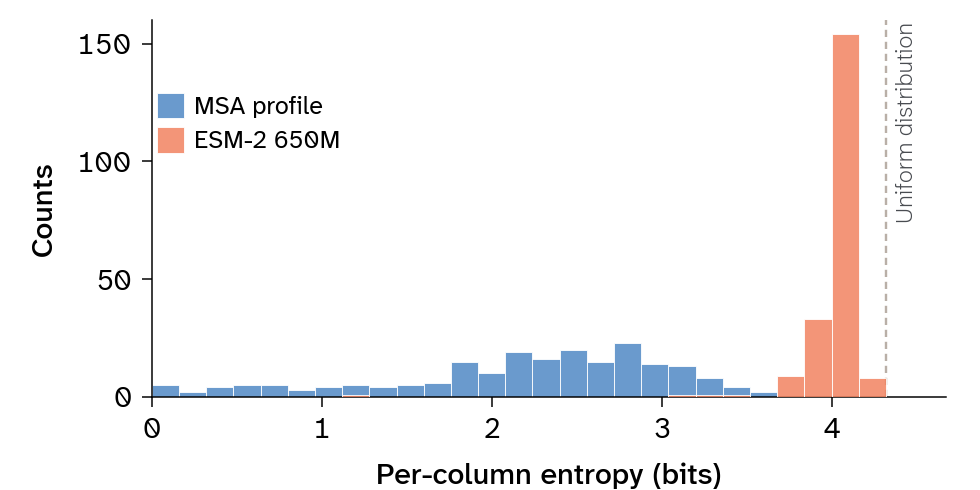

In [4]:
fig, ax = plt.subplots(figsize=(HALF_SQUARE * PX, HALF_SQUARE * 0.50 * PX))
fig.subplots_adjust(left=0.155, right=0.965, bottom=0.19, top=0.96)

bins = np.arange(0, MAXH + 0.16, 0.16)
ax.hist(col.H_fam, bins=bins, color=C_FAM, alpha=0.85, edgecolor="white", linewidth=0.5,
        label="MSA profile", zorder=2)
ax.hist(col.H_esm, bins=bins, color=C_ESM, alpha=0.85, edgecolor="white", linewidth=0.5,
        label="ESM-2 650M", zorder=3)
ax.axvline(MAXH, color=NEUTRAL, lw=1.2, ls=(0, (3, 2)), zorder=1)
ax.set_xlim(0, MAXH + 0.35)
ax.set_xlabel("Per-column entropy (bits)")
ax.set_ylabel("Counts")
finish(ax)
ymax = ax.get_ylim()[1]
ax.annotate("Uniform distribution", xy=(MAXH + 0.06, ymax * 0.995), rotation=90, ha="left",
            va="top", fontsize=12, fontweight="ultralight", color=str(apc.charcoal),
            linespacing=1.25)
leg = ax.legend(loc="upper left", frameon=False, fontsize=12.5, handlelength=1.1,
                labelspacing=0.35, borderpad=0.2, bbox_to_anchor=(0.0, 0.82))
style_key(leg)

save(fig, "esm_vs_msa_entropy")
plt.show()

**Figure 1. The family is decided at many positions; ESM-2 is decided at almost none of them.**
Entropy of the residue distribution at each of the 208 near-complete alignment columns, under the
Henikoff-weighted family frequency (aegean) and under the ESM-2 650M masked marginal on the EGFP scaffold
(amber). The family's distribution spans the full range — 12% of columns sit below 1 bit, i.e. one
residue in ≥ 90% of the weighted family — while ESM-2's never leaves the top corner: 98% of columns
above 3.5 bits, none below 1, against a 4.32-bit ceiling.
**Take away:** the ESM-2 term in the design objective is close to constant across residues at most
positions of this barrel, while the family's is not.

## 2. The flatness belongs to the fold, not to the measurement

A model that is uncertain everywhere could just as easily mean a broken harness as an
uninformative model. The same code path, run over three ordinary proteins spanning the FPs' own
length range, separates those two readings.

ubiquitin  L= 76  mean 1.12  median 1.01  min 0.015  frac < 0.1 bits 0.16
lysozyme   L=129  mean 1.40  median 1.25  min 0.001  frac < 0.1 bits 0.12
trypsin    L=223  mean 1.42  median 1.33  min 0.002  frac < 0.1 bits 0.13
mCherry    L=236  mean 3.85  median 3.98  min 1.451  frac < 0.1 bits 0.00
EGFP       L=239  mean 4.04  median 4.09  min 1.246  frac < 0.1 bits 0.00
avGFP      L=238  mean 4.05  median 4.10  min 1.013  frac < 0.1 bits 0.00


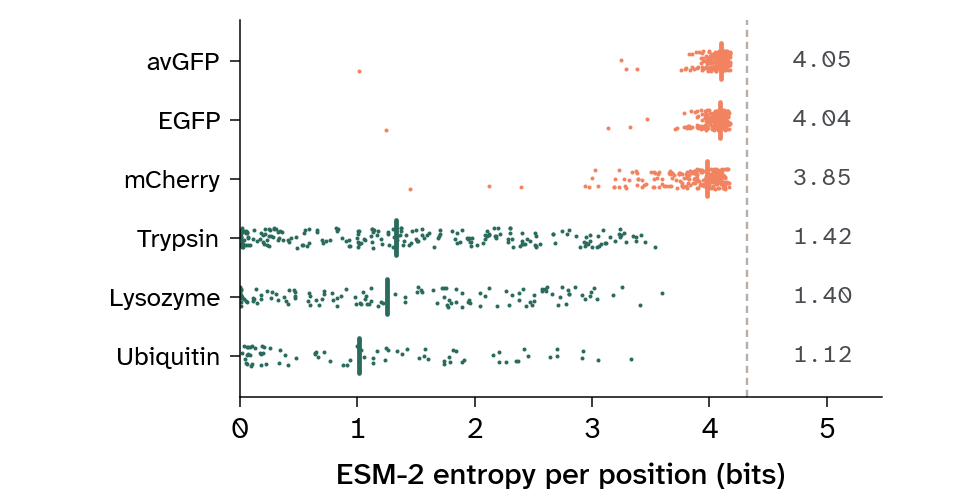

In [5]:
fig, ax = plt.subplots(figsize=(HALF_SQUARE * PX, HALF_SQUARE * 0.50 * PX))
fig.subplots_adjust(left=0.245, right=0.90, bottom=0.19, top=0.96)

order = ["ubiquitin", "lysozyme", "trypsin", "mCherry", "EGFP", "avGFP"]
for k, name in enumerate(order):
    H = entropy_bits(prof[name])
    c = C_CTRL if pmeta["group"][name] == "control" else C_ESM
    ax.scatter(H, np.full(len(H), k) + np.linspace(-0.17, 0.17, len(H)), s=4, color=c,
               alpha=1, linewidths=0, zorder=2)
    ax.plot([np.median(H)] * 2, [k - 0.30, k + 0.30], color=c, lw=2.4, zorder=3)
    ax.annotate(f"{np.mean(H):.2f}", xy=(0.86, k), xycoords=("axes fraction", "data"),
                va="center", ha="left", fontfamily="Atkinson Hyperlegible Mono", fontsize=12,
                color=str(apc.charcoal), annotation_clip=False)
ax.axvline(MAXH, color=NEUTRAL, lw=1.2, ls=(0, (3, 2)), zorder=1)
ax.set_yticks(range(len(order)))
ax.set_yticklabels([n.capitalize() if pmeta["group"][n] == "control" else n for n in order],
                   fontsize=13)
ax.set_ylim(-0.7, len(order) - 0.3)
ax.set_xlim(0, MAXH + 1.15)
ax.set_xlabel("ESM-2 entropy per position (bits)")
finish(ax, mono="x")

for name in order:
    H = entropy_bits(prof[name])
    print(f"{name:<10} L={len(H):>3}  mean {H.mean():.2f}  median {np.median(H):.2f}  "
          f"min {H.min():.3f}  frac < 0.1 bits {np.mean(H < 0.1):.2f}")

save(fig, "esm_vs_msa_control_calibration")
plt.show()

**Figure 2. The same measurement on ordinary proteins of the same length.** ESM-2 masked-marginal
entropy at every position of three FPs and three non-fluorescent controls, produced by identical
code. Ubiquitin (76 aa), lysozyme (129) and trypsin (223) average 1.1–1.4 bits and put 12–16% of their
positions below 0.1 bits; avGFP (238), EGFP (239) and mCherry (236) average 3.8–4.1 and never once
drop that low.
**Take away:** the flatness in Figure 1 is neither a harness bug nor a length effect — trypsin sits
within a dozen residues of the FPs and behaves like the 76-residue control. It is a property of
ESM-2 on this fold.

## 3. And they are not flat and sharp about the *same* positions

Figure 1 leaves one possibility open: ESM-2 could be a compressed version of the same
signal — weakly preferring the same residues where the family is decided. Column-by-column, it is
not. Whatever residual structure the ESM-2 distribution has on this fold is uncorrelated with the
family's, and the disagreement grows precisely where the family's evidence is strongest.

A: ρ(H_fam, H_esm) = +0.054, p = 0.44
B: ρ(C_chem, JS) = +0.686, p = 3.3e-30
   mean JS 0.681 at the 27 chemistry-locked columns vs 0.306 at the 55 most permissive


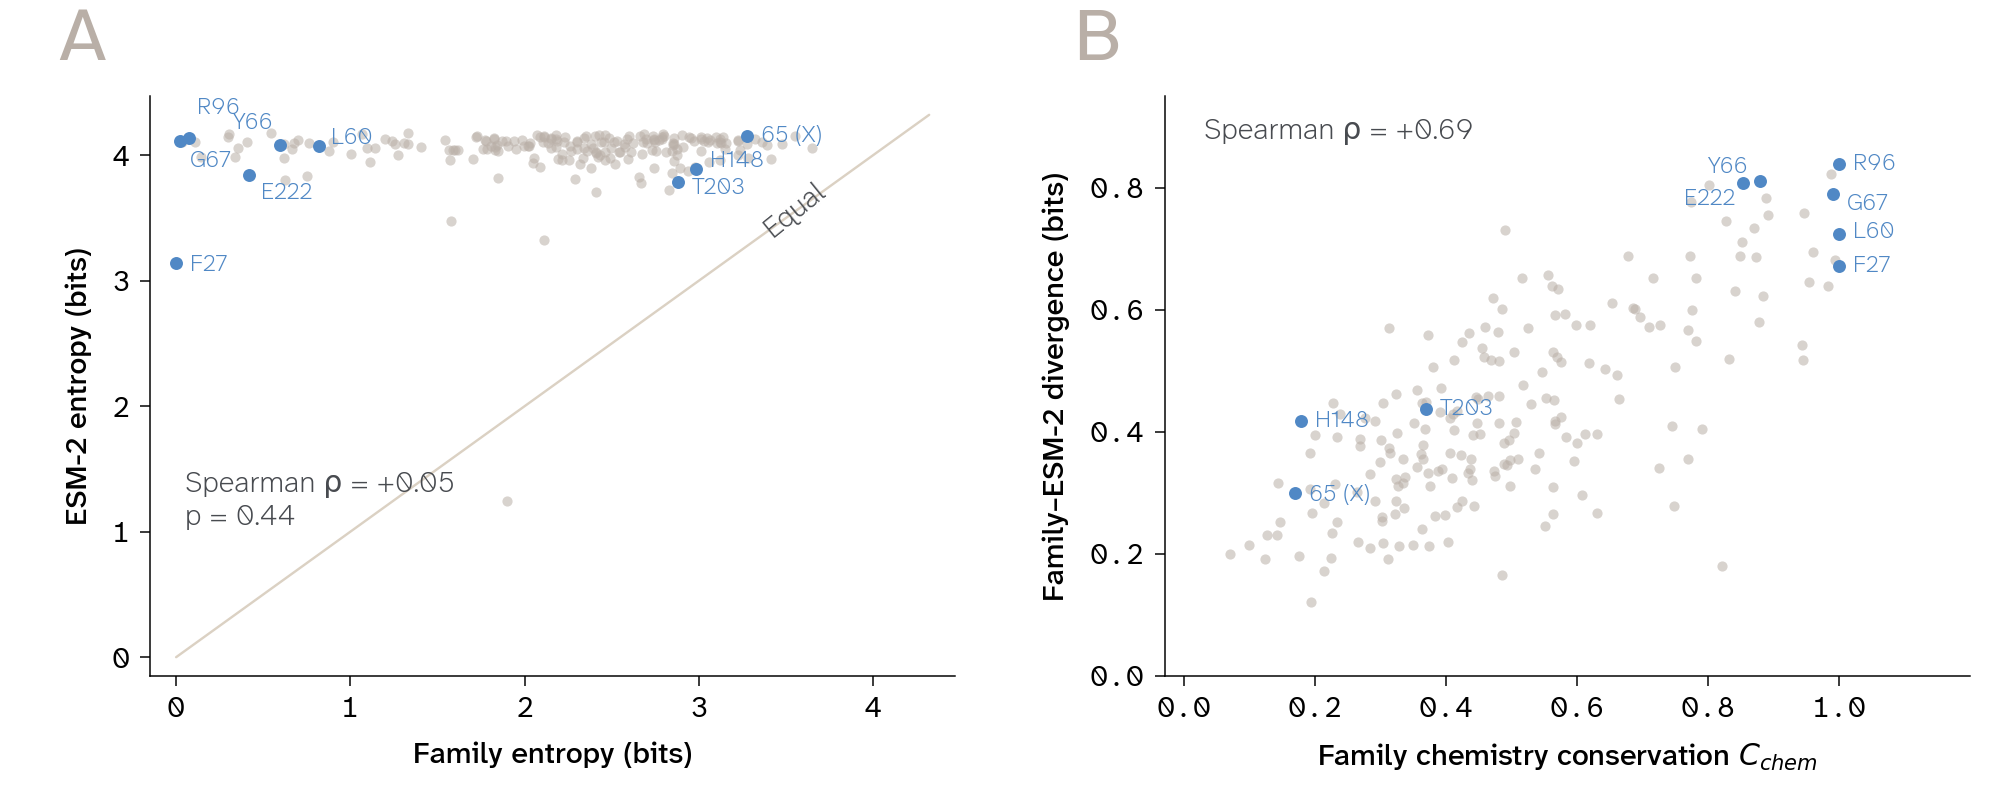

In [6]:
fig, (axA, axB) = plt.subplots(1, 2, figsize=(FULL_WIDE * PX, FULL_WIDE * 0.40 * PX))
fig.subplots_adjust(left=0.075, right=0.985, bottom=0.155, top=0.88, wspace=0.26)

LAND = {96: "R96", 67: "G67", 66: "Y66", 60: "L60", 222: "E222", 27: "F27",
        65: "65 (X)", 148: "H148", 203: "T203"}
# hand offsets, in points, where two landmarks would otherwise print on top of each other
NUDGE_A = {96: (4, 12), 67: (5, -13), 66: (-4, 8), 60: (6, 1), 222: (6, -12), 27: (7, -4),
           65: (7, -3), 148: (7, 1), 203: (7, -6)}
NUDGE_B = {96: (7, -3), 67: (7, -8), 66: (-6, 4), 222: (-4, -11), 60: (7, -2), 27: (7, -3),
           65: (7, -4), 148: (7, -3), 203: (7, -3)}

# --- A: family entropy vs ESM-2 entropy, one point per column --------------------------------
axA.plot([0, MAXH], [0, MAXH], color=NEUTRAL_SOFT, lw=1.2, zorder=1)
axA.scatter(col.H_fam, col.H_esm, s=26, color=NEUTRAL, alpha=0.55, linewidths=0, zorder=2)
sel = col[col.ref_pos.isin(LAND)]
axA.scatter(sel.H_fam, sel.H_esm, s=42, color=C_FAM, linewidths=0, zorder=3)
for r in sel.itertuples():
    dx, dy = NUDGE_A[int(r.ref_pos)]
    axA.annotate(LAND[int(r.ref_pos)], xy=(r.H_fam, r.H_esm), xytext=(dx, dy),
                 textcoords="offset points", ha="right" if dx < 0 else "left",
                 fontsize=12, fontweight="ultralight", color=C_FAM)
axA.set_xlim(-0.15, MAXH + 0.15); axA.set_ylim(-0.15, MAXH + 0.15)
axA.set_xlabel("Family entropy (bits)"); axA.set_ylabel("ESM-2 entropy (bits)")
finish(axA)
rho = spearmanr(col.H_fam, col.H_esm)
axA.annotate(f"Spearman ρ = {rho.statistic:+.2f}\np = {rho.pvalue:.2f}", xy=(0.05, 1.05),
             color=str(apc.charcoal), fontsize=15, fontweight="ultralight", linespacing=1.3)
axA.annotate("Equal", xy=(3.55, 3.35), rotation=39, ha="center", **ANNOTATION)
panel_letter(axA, "A")

# --- B: disagreement against how hard the family holds the position --------------------------
axB.scatter(col.C_chem, col.js, s=26, color=NEUTRAL, alpha=0.55, linewidths=0, zorder=2)
axB.scatter(sel.C_chem, sel.js, s=42, color=C_FAM, linewidths=0, zorder=3)
for r in sel.itertuples():
    dx, dy = NUDGE_B[int(r.ref_pos)]
    axB.annotate(LAND[int(r.ref_pos)], xy=(r.C_chem, r.js), xytext=(dx, dy),
                 textcoords="offset points", ha="right" if dx < 0 else "left",
                 fontsize=12, fontweight="ultralight", color=C_FAM)
axB.set_xlim(-0.03, 1.20); axB.set_ylim(0, 0.95)
axB.set_xticks(np.arange(0, 1.01, 0.2))
axB.set_xlabel("Family chemistry conservation $C_{chem}$")
axB.set_ylabel("Family–ESM-2 divergence (bits)")
finish(axB)
rho2 = spearmanr(col.C_chem, col.js)
axB.annotate(f"Spearman ρ = {rho2.statistic:+.2f}", xy=(0.03, 0.88),
             color=str(apc.charcoal), fontsize=15, fontweight="ultralight")
panel_letter(axB, "B")

print(f"A: ρ(H_fam, H_esm) = {rho.statistic:+.3f}, p = {rho.pvalue:.2f}")
print(f"B: ρ(C_chem, JS) = {rho2.statistic:+.3f}, p = {rho2.pvalue:.1e}")
lock, free = col[col.C_chem >= 0.8], col[col.C_chem < 0.35]
print(f"   mean JS {lock.js.mean():.3f} at the {len(lock)} chemistry-locked columns "
      f"vs {free.js.mean():.3f} at the {len(free)} most permissive")
save(fig, "esm_vs_msa_disagreement")
plt.show()

**Figure 3. The two distributions carry uncorrelated information, and diverge most where the
family is most certain.**
**(A)** Per-column entropy under the family against entropy under ESM-2, 208 core columns, equal
axes with the identity line. All but one column sits above the diagonal — ESM-2 is more
uncertain than the family at 207 of the 208, the exception being the initiator Met — and the
vertical spread carries no signal: Spearman ρ = +0.05
(p = 0.44). Knowing how constrained a column is in the family tells you nothing about how
constrained ESM-2 thinks it is.
**(B)** Jensen–Shannon divergence between the two distributions against the family's chemistry
conservation `C_chem`, ρ = +0.69. The catalytic pair R96/E222, the cyclization glycine G67, the
chromophore ring Y66 and the fully buried L60 — the positions the family refuses to vary — are the
positions where ESM-2's opinion is furthest from the family's.
**Take away:** these are not two estimates of one quantity. The disagreement is systematic and
concentrated on the positions that carry the family's information, so an objective that already
contains the ESM-2 term is missing that information entirely rather than double-counting it.

## 4. What the disagreement looks like at single positions

Divergence in bits is abstract; the distributions themselves are not. Six positions, three the
family locks and three it leaves open, plotted as mirrored 20-residue distributions — family above
the axis, ESM-2 below.

The ESM-2 side is taken on **EGFP**, as everywhere else in this notebook, because these are the
residues the campaign actually proposes over. The MSA profile is unaffected by that choice — it is
a property of the alignment column, not of any one member — and avGFP gives nearly the same ESM-2
answer anyway (mean |ΔJS| = 0.012 bits over the 208 columns, printed in section 0). What the
scaffold buys is the right residue letter: EGFP's chromophore X is Thr, not avGFP's Ser.

**Numbering.** Positions stay in **avGFP numbering** throughout, as everywhere else in this folder
and as the GFP literature has used since Ormö and Yang — Ser65-Tyr66-Gly67 for the chromophore
triad, Arg96 and Glu222 for the catalytic pair, Thr203 for the residue whose T203Y substitution
makes YFP. Note that the campaign's own `design_windows_egfp_tierB.json` numbers the 239-residue
EGFP construct instead, which carries an extra Val at position 2 and so runs one higher: L60 here
is the L61 of those files, and Figure 7 keeps that construct numbering because it is reporting on
the window definition itself.

R96   (EGFP construct 97 , avGFP R96)  family RKA [0.99 0.01 0.  ]   ESM-2 GAK [0.121 0.079 0.076]   JS 0.84  p(family top) 0.048
G67   (EGFP construct 68 , avGFP G67)  family GAD [1. 0. 0.]   ESM-2 LAG [0.131 0.087 0.078]   JS 0.79  p(family top) 0.078
Y66   (EGFP construct 67 , avGFP Y66)  family YRW [0.91 0.04 0.03]   ESM-2 GSE [0.096 0.088 0.083]   JS 0.81  p(family top) 0.030
L60   (EGFP construct 61 , avGFP L60)  family LIV [0.84 0.11 0.03]   ESM-2 GPD [0.104 0.088 0.086]   JS 0.72  p(family top) 0.059
T65   (EGFP construct 66 , avGFP S65)  family QGM [0.2  0.19 0.16]   ESM-2 GKA [0.086 0.083 0.081]   JS 0.30  p(family top) 0.052
T203  (EGFP construct 204, avGFP T203)  family HRT [0.37 0.19 0.13]   ESM-2 LIV [0.197 0.147 0.116]   JS 0.44  p(family top) 0.016


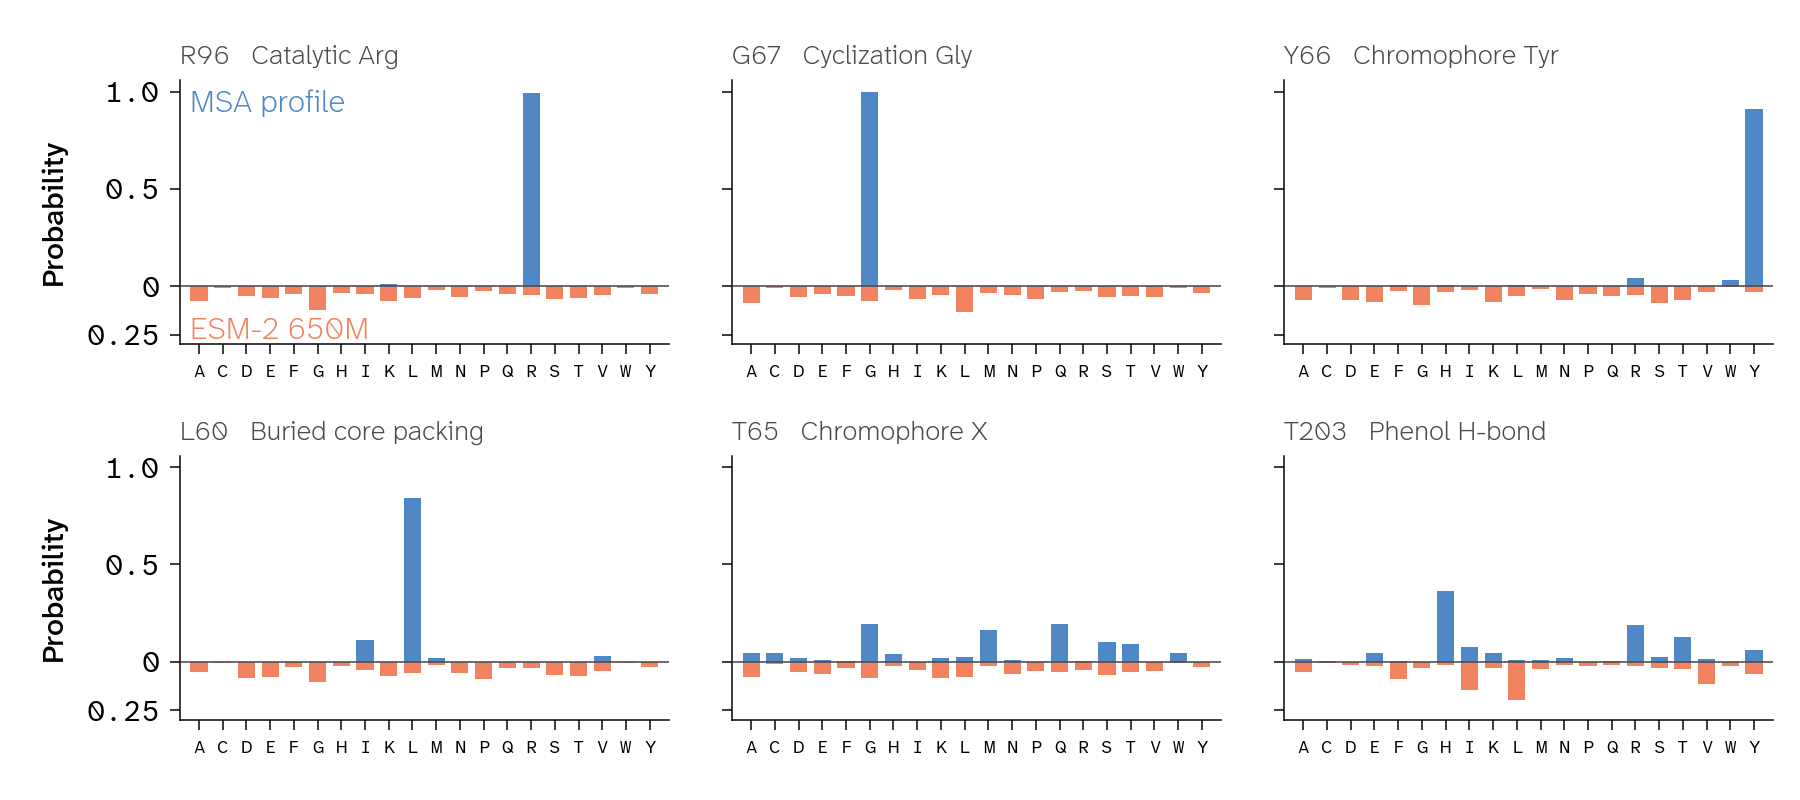

In [7]:
SHOW = [(96, "Catalytic Arg"), (67, "Cyclization Gly"), (66, "Chromophore Tyr"),
        (60, "Buried core packing"), (65, "Chromophore X"), (203, "Phenol H-bond")]

fig, axes = plt.subplots(2, 3, figsize=(0.9 * FULL_WIDE * PX, FULL_WIDE * 0.4 * PX), sharey=True)
fig.subplots_adjust(left=0.1, right=0.985, bottom=0.10, top=0.90, wspace=0.13, hspace=0.42)
x = np.arange(20)

for ax, (pos, role) in zip(axes.ravel(), SHOW):
    i = int(np.nonzero(col.ref_pos.to_numpy() == pos)[0][0])
    ax.bar(x, F[i], width=0.72, color=C_FAM, linewidth=0, zorder=3)
    ax.bar(x, -E[i], width=0.72, color=C_ESM, linewidth=0, zorder=3)
    ax.axhline(0, color=str(apc.charcoal), lw=0.8, zorder=4)
    ax.set_xticks(x)
    ax.set_xticklabels(list(AAS), fontsize=9, fontfamily="Atkinson Hyperlegible Mono")
    # both halves are on ONE probability scale -- the lower half is only cropped, not rescaled,
    # so the size difference between the two distributions is read directly off the axis
    ax.set_xlim(-0.8, 19.8); ax.set_ylim(-0.30, 1.06)
    ax.set_yticks([-0.25, 0, 0.5, 1.0])
    ax.set_yticklabels(["0.25", "0", "0.5", "1.0"])
    finish(ax, mono="y")
    ax.annotate(f"{col.esm_aa[i]}{pos}   {role}", xy=(0, 1), xycoords="axes fraction",
                xytext=(0, 8), textcoords="offset points", fontsize=14,
                fontweight="ultralight", color=str(apc.charcoal))

for ax in axes[:, 0]:
    ax.set_ylabel("Probability")
axes[0, 0].annotate("MSA profile", xy=(0.02, 0.88), xycoords="axes fraction", color=C_FAM,
                    fontsize=16, fontweight="ultralight")
axes[0, 0].annotate("ESM-2 650M", xy=(0.02, 0.02), xycoords="axes fraction", color=C_ESM,
                    fontsize=16, fontweight="ultralight")
for pos, _ in SHOW:
    i = int(np.nonzero(col.ref_pos.to_numpy() == pos)[0][0])
    ft = "".join(AAS[j] for j in np.argsort(-F[i])[:3])
    et = "".join(AAS[j] for j in np.argsort(-E[i])[:3])
    print(f"{col.esm_aa[i]}{pos:<4} (EGFP construct {pos + 1:<3}, avGFP {col.ref_aa[i]}{pos})  "
          f"family {ft} {np.sort(F[i])[::-1][:3].round(2)}   "
          f"ESM-2 {et} {np.sort(E[i])[::-1][:3].round(3)}   JS {col.js[i]:.2f}  "
          f"p(family top) {E[i][int(F[i].argmax())]:.3f}")
save(fig, "esm_vs_msa_positions")
plt.show()

**Figure 4. Six positions, both distributions, same axis.** MSA profile plotted upward, ESM-2
masked marginal on the EGFP scaffold downward, all 20 residues in alphabetical order. Positions are
in avGFP numbering with EGFP's residue letters, so 65 reads Thr (EGFP is avGFP F64L/S65T).
**Top row, the positions the family locks:** R96 polarizes the imidazolinone carbonyl during
maturation and is 99% Arg; G67 supplies the backbone nitrogen that attacks it to close the ring and
is 99.8% Gly; Y66 is the chromophore's own phenol, 91% Tyr with the remainder the Trp/His of
engineered cyan and blue variants. Under ESM-2 all three are near-uniform, its top choice being
Gly, Leu and Gly respectively — at R96 it puts 0.12 on Gly and 0.05 on the Arg every member of the
family carries.
**Bottom left, L60:** not a named position in the GFP literature and not in contact with the
chromophore — 4.8 Å away at the closest heavy atom — but wholly inaccessible to solvent (RSA 0.00)
and filled by Leu, Ile, Val or Met in all 763 sequences, 84% of them Leu. ESM-2's top three there
are Gly, Pro and Asp, none of which the family ever uses.
**Bottom centre and right, the positions the family leaves open** — the chromophore X of the X-Y-G
triad, where the family holds Gln/Gly/Met/Ser/Thr and so recovers the QYG of DsRed and the (S/T)YG
of the GFPs, and Thr203, whose hydroxyl hydrogen-bonds the chromophore phenol at 3.5 Å and whose
T203Y substitution is what makes YFP. Here both distributions are diffuse and their divergence is
roughly half that of the top row.
**Take away:** where the family is informative, ESM-2 is not merely vaguer — it prefers residues
the family has ruled out. That is the failure mode a top-*k* sampler inherits directly.

## 5. Along the barrel

The same comparison laid out in avGFP numbering, so the structure is visible: the family's
constraint has sharp position-to-position structure that tracks the fold, and ESM-2's is a flat
band with no relation to it.

family entropy: -0.00-3.65 bits (range 3.65)
ESM-2 entropy:  1.25-4.18 bits (range 2.93)
mean JS  pocket (<5 Å, n=28) 0.473  vs scaffold 0.433
mean JS  buried (RSA<0.15, n=99) 0.506  vs exposed 0.378


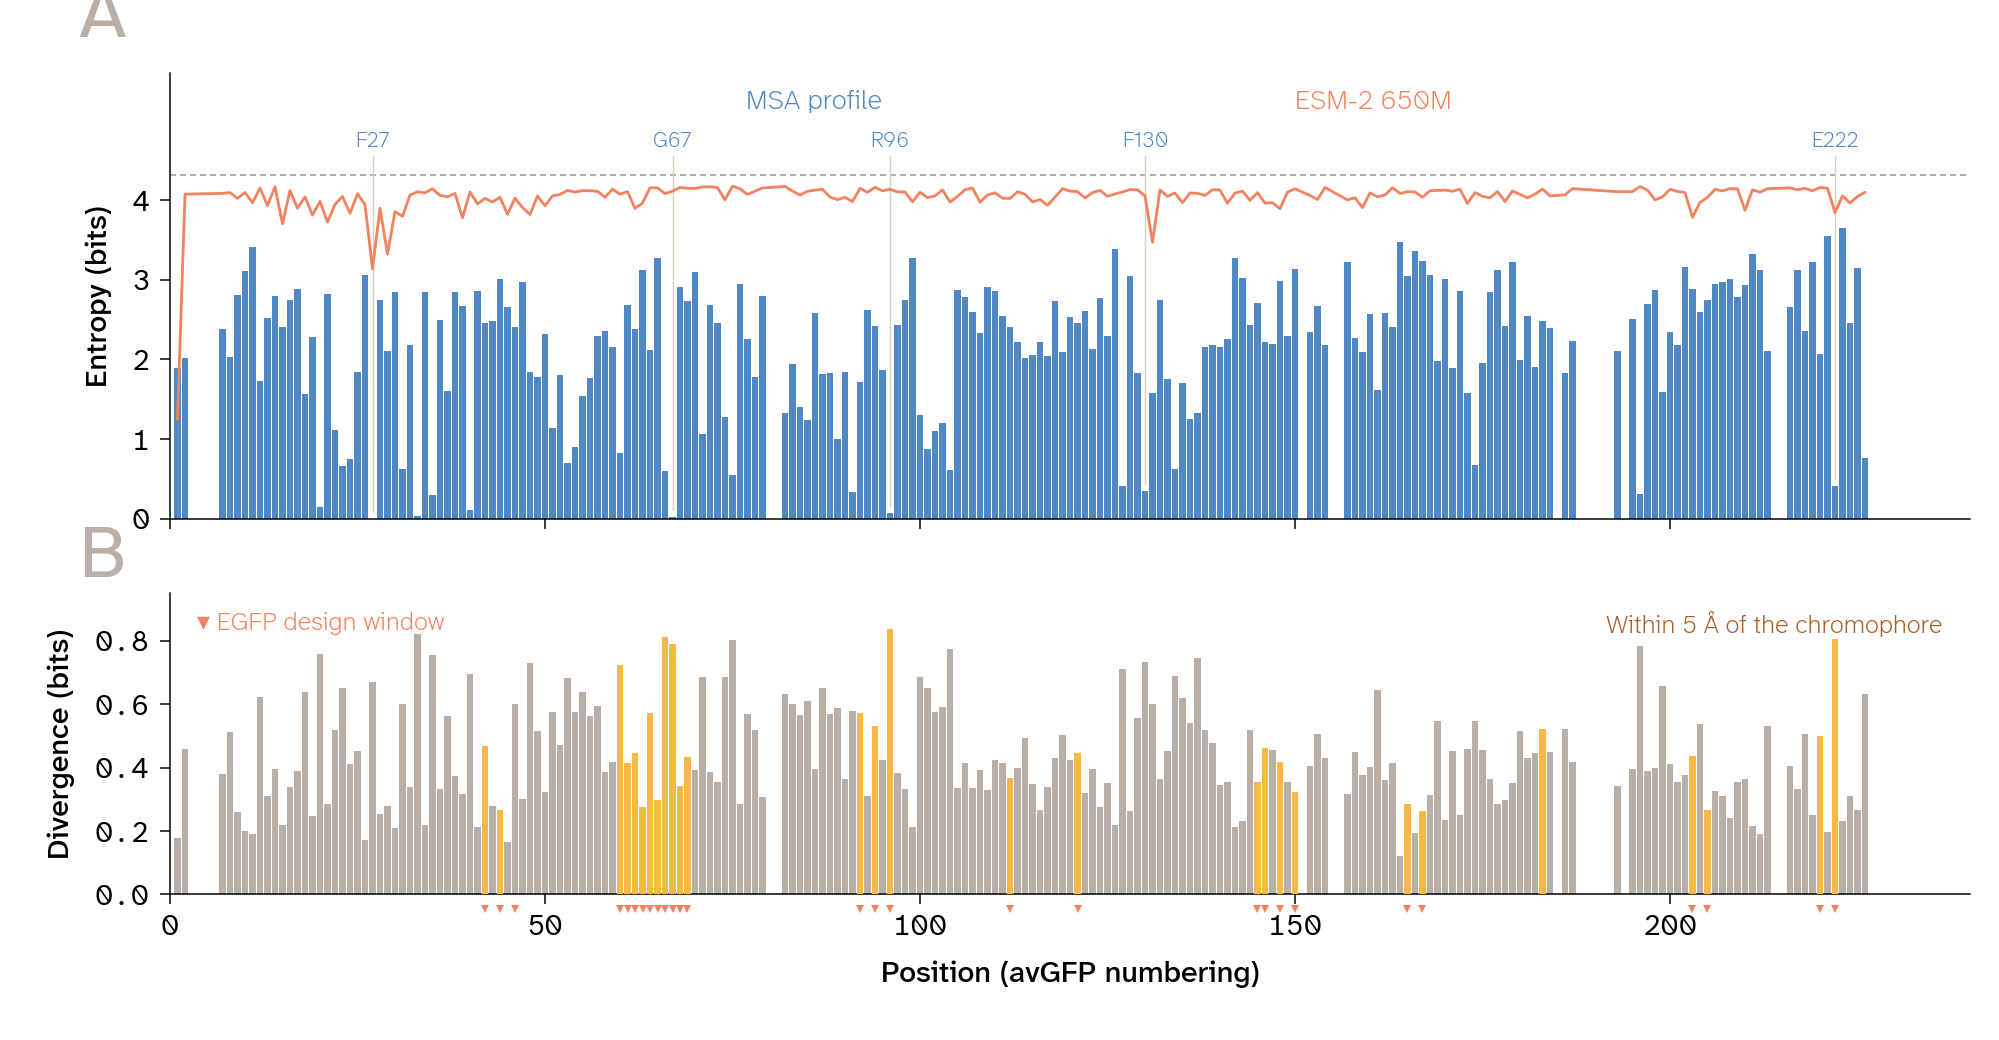

In [8]:
d = col.sort_values("ref_pos")
x = d.ref_pos.to_numpy()
win = pd.read_csv("results/window_vs_family_egfp.csv")
win_pos = set(win.avgfp_pos)
# the same five landmarks plot_conservation.py names on its track panel; 60/66 crowd the 60-70 region
TRACK_LANDMARK = {27: "F27", 67: "G67", 96: "R96", 130: "F130", 222: "E222"}

fig, ax = plt.subplots(2, 1, figsize=(FULL_WIDE * PX, FULL_WIDE * 0.52 * PX), sharex=True,
                       gridspec_kw=dict(height_ratios=[2.0, 1.35], hspace=0.20))
fig.subplots_adjust(left=0.085, right=0.985, bottom=0.14, top=0.93)

# --- A: entropy of both distributions along the sequence -------------------------------------
ax[0].bar(x, d.H_fam, width=0.9, color=C_FAM, linewidth=0, zorder=2)
ax[0].plot(x, d.H_esm, lw=1.4, color=C_ESM, zorder=3)
ax[0].axhline(MAXH, color=NEUTRAL, lw=1.0, ls=(0, (3, 2)), zorder=1)
ax[0].set_ylim(0, 5.6); ax[0].set_yticks([0, 1, 2, 3, 4])
ax[0].set_ylabel("Entropy (bits)")
finish(ax[0], mono="y")
# in-place series labels rather than a key: the bars leave no corner a key could sit in
ax[0].annotate("ESM-2 650M", xy=(150, 5.15), color=C_ESM, fontsize=14, fontweight="ultralight")
ax[0].annotate("MSA profile", xy=(95, 5.15), ha="right", color=C_FAM, fontsize=14,
               fontweight="ultralight")
for p, lab in TRACK_LANDMARK.items():
    if p in set(x):
        h = float(d.loc[d.ref_pos == p, "H_fam"].iloc[0])
        ax[0].plot([p, p], [h + 0.08, 4.55], lw=0.7, color=NEUTRAL_SOFT, zorder=1)
        ax[0].annotate(lab, xy=(p, 4.62), ha="center", va="bottom", fontsize=11,
                       fontweight="ultralight", color=C_FAM)

# --- B: divergence, with the pocket and the EGFP window marked -------------------------------
ax[1].bar(x, d.js, width=0.9, color=NEUTRAL, linewidth=0, zorder=2)
inpocket = d.chromo_dist < 5
ax[1].bar(x[inpocket], d.js[inpocket], width=0.9, color=C_POCKET, linewidth=0, zorder=3)
ax[1].set_ylim(0, 0.95); ax[1].set_ylabel("Divergence (bits)")
ax[1].set_xlabel("Position (avGFP numbering)")
ax[1].set_xlim(0, 240)
finish(ax[1])
for p in sorted(win_pos):
    ax[1].plot([p], [-0.045], marker="v", ms=3.6, color=C_ESM, clip_on=False, zorder=4)
ax[1].annotate("▾ EGFP design window", xy=(0.015, 0.94), xycoords="axes fraction", va="top",
               color=C_ESM, fontsize=13, fontweight="ultralight")
ax[1].annotate("Within 5 Å of the chromophore", xy=(0.985, 0.94), xycoords="axes fraction",
               ha="right", va="top", color=str(apc.umber), fontsize=13, fontweight="ultralight")
panel_letter(ax[0], "A"); panel_letter(ax[1], "B", dy=2)

print(f"family entropy: {d.H_fam.min():.2f}-{d.H_fam.max():.2f} bits (range {d.H_fam.max()-d.H_fam.min():.2f})")
print(f"ESM-2 entropy:  {d.H_esm.min():.2f}-{d.H_esm.max():.2f} bits (range {d.H_esm.max()-d.H_esm.min():.2f})")
print(f"mean JS  pocket (<5 Å, n={int(inpocket.sum())}) {d.js[inpocket].mean():.3f}  "
      f"vs scaffold {d.js[~inpocket].mean():.3f}")
print(f"mean JS  buried (RSA<0.15, n={int((d.rsa<0.15).sum())}) {d.js[d.rsa < 0.15].mean():.3f}  "
      f"vs exposed {d.js[d.rsa >= 0.15].mean():.3f}")
save(fig, "esm_vs_msa_barrel_track")
plt.show()

**Figure 5. The comparison along the barrel.**
**(A)** Per-position entropy of the family distribution (aegean bars) and of the ESM-2 masked
marginal (amber line) in avGFP numbering, over the 208 near-complete columns; the dashed line at
4.32 bits is a flat distribution over all 20 residues. The family track
swings across the full 0–3.7 bit range with recognisable structure — the deep notches are the
conserved glycines, the catalytic dyad and the chromophore triad. The ESM-2 track is a flat band
that drops below 3.5 bits at 4 of 208 positions and below 3 bits at exactly one, the initiator
Met, and shows no correspondence with the notches.
**(B)** Jensen–Shannon divergence at each position, with the 5 Å chromophore shell in canary and
the EGFP design window marked below the axis. Divergence is slightly higher inside the pocket
(0.47 vs 0.43 bits) and, more informatively, higher at buried positions (0.51) than exposed ones
(0.38) — burial is where the family's constraint lives, so it is also where the two disagree.
**Take away:** the family signal has structure the model does not reproduce anywhere along the
chain, including inside the window the campaign edits.

## 6. Every FP in the family, and which of the two distributions is right

Two things remain to be ruled out. First, that this is an EGFP/avGFP idiosyncrasy — Figure 2
compared FPs against non-FPs, not FPs against each other, so it is still possible that the three
sequences used there are unrepresentative. Answered by running the same measurement over a
clade-stratified sample of 96 proteins from the alignment, spanning 81 source organisms. Second,
that the family profile is merely *sharper* without being more accurate — answered by asking each
distribution to predict the residue a protein actually carries, with that protein removed from the
family profile first.

The leave-one-out family profile subtracts the protein's own Henikoff weight from every column it
occupies, so no protein is scored against evidence it supplied. Perplexity is
`2^(−mean log₂ p(true residue))`: 1 means certainty, 20 means a coin flip over all residues, and
**18.2 is what you get for free** from the family's background amino-acid composition alone.

A  mean confidence: FP 0.134 (range 0.111-0.169), control 0.708 (range 0.682-0.754)
   by clade: Aequorea 0.122 (n=4), Anthozoa 0.141 (n=24), Other FP 0.132 (n=68)
   FP top-1 accuracy 0.147 vs control 0.732
B  perplexity  family (LOO) 4.93  ESM-2 16.00  background 18.21
   top-1 accuracy on the true residue: family 53.3%  ESM-2 15.1%   family better for 96/96


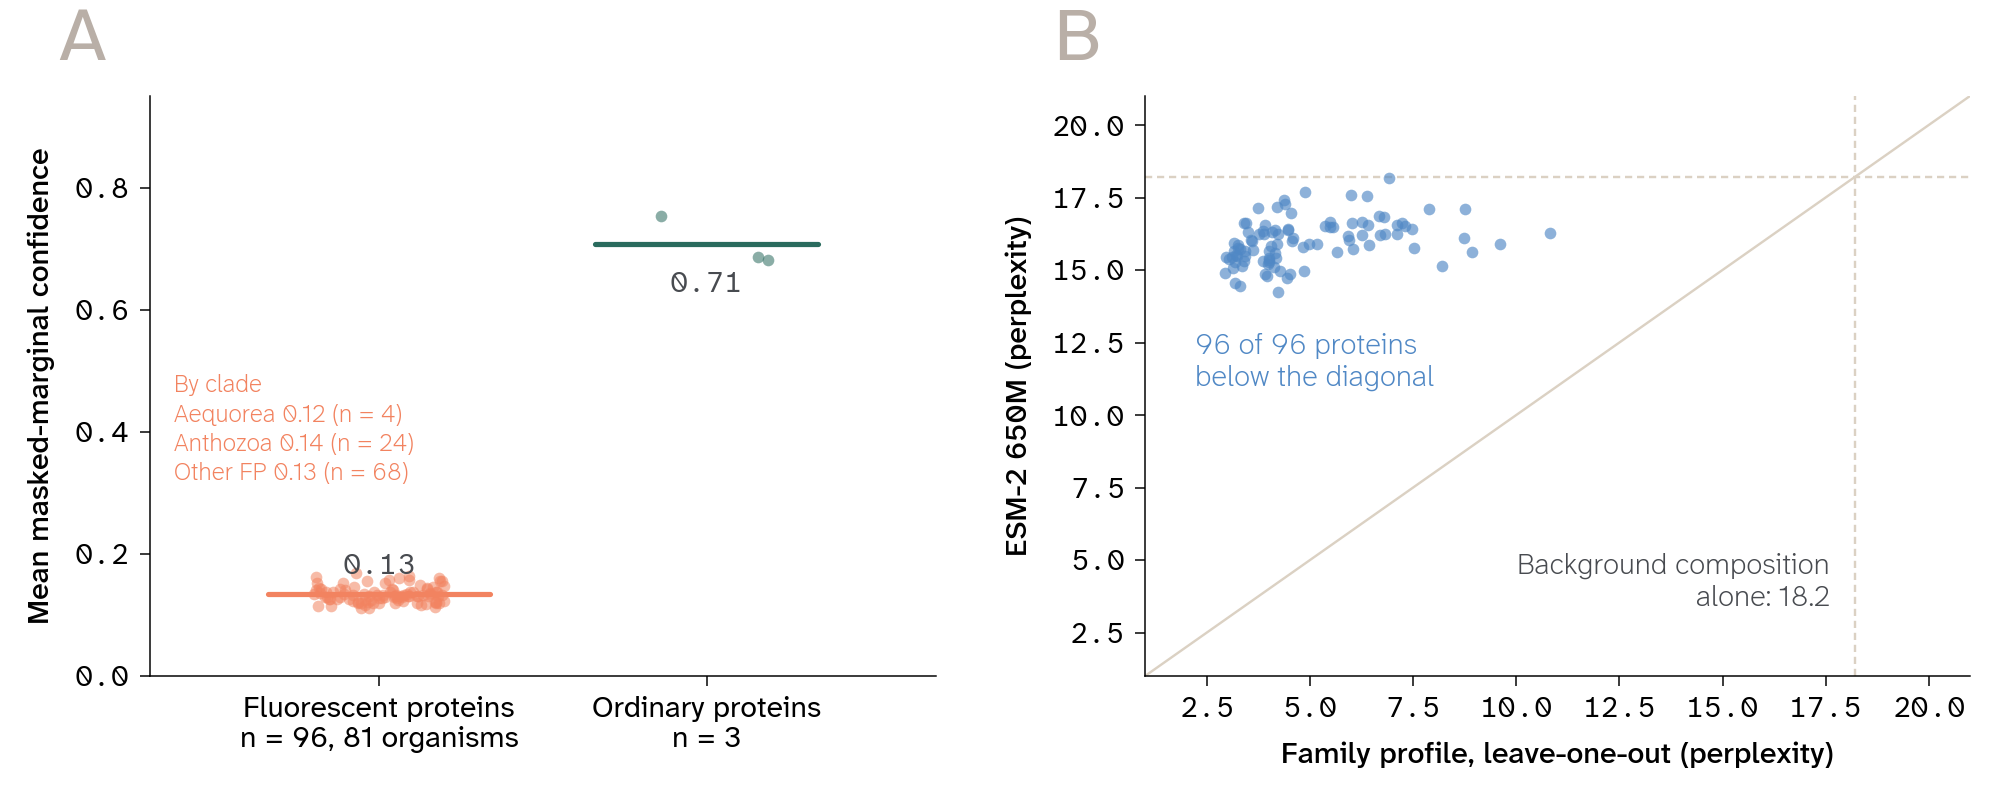

In [9]:
sweep = pd.read_csv("results/esm_family_sweep.csv")
sw_prof = dict(np.load("results/esm_sweep_profiles.npz"))
fps, ctrls = sweep[sweep.clade != "Control"], sweep[sweep.clade == "Control"]

# --- leave-one-out family profile vs ESM-2, per sampled protein ------------------------------
A, aln_meta = cv.load_alignment()
code_full = cv.encode(A)
occ_full = (code_full >= 0).mean(0)
w = cv.henikoff_weights(code_full[:, occ_full >= 0.50])        # weights exactly as conservation.py
cols_hi = cons[cons.occupancy >= 0.90].aln_col.to_numpy()
Cc = code_full[:, cols_hi]
W = np.stack([np.bincount(Cc[Cc[:, j] >= 0, j], minlength=20, weights=w[Cc[:, j] >= 0])
              for j in range(len(cols_hi))])                   # weighted counts per core column
row_of = {s: i for i, s in enumerate(aln_meta.slug)}

rows = []
for r in fps.itertuples():
    i, P = row_of[r.slug], sw_prof[r.slug]
    res_idx = np.cumsum(code_full[i] >= 0) - 1                 # alignment column -> residue index
    lp_f, lp_e, hit_f, hit_e = [], [], [], []
    for j, c in enumerate(cols_hi):
        a = code_full[i, c]
        k = res_idx[c]
        if a < 0 or k >= len(P):
            continue
        Wl = W[j].copy()
        Wl[a] = max(Wl[a] - w[i], 0.0)                         # leave this protein out
        if Wl.sum() <= 0:
            continue
        f = Wl / Wl.sum()
        lp_f.append(np.log2(f[a] + 1e-6)); hit_f.append(int(f.argmax()) == a)
        lp_e.append(np.log2(P[k][a] + 1e-6)); hit_e.append(int(P[k].argmax()) == a)
    rows.append(dict(slug=r.slug, clade=r.clade, n=len(lp_f),
                     ppl_fam=2 ** -np.mean(lp_f), ppl_esm=2 ** -np.mean(lp_e),
                     acc_fam=np.mean(hit_f), acc_esm=np.mean(hit_e)))
pred = pd.DataFrame(rows)
PPL_BG = 2 ** summary["H_background"]

fig, (axA, axB) = plt.subplots(1, 2, figsize=(FULL_WIDE * PX, FULL_WIDE * 0.40 * PX),
                               width_ratios=[1, 1.05])
fig.subplots_adjust(left=0.075, right=0.985, bottom=0.155, top=0.88, wspace=0.26)

# --- A: masked-marginal sharpness across the family and the controls -------------------------
# The round-robin sample is one or two proteins per source organism, so the clades are very
# unevenly sized (Aequorea n = 4); they are reported as means under the FP strip rather than
# split into their own categories, which would headline an n = 4 group.
rng = np.random.default_rng(0)
for k, (mask, c) in enumerate(((sweep.clade != "Control", C_ESM),
                               (sweep.clade == "Control", C_CTRL))):
    v = sweep.loc[mask, "mean_max_prob"].to_numpy()
    axA.scatter(np.full(len(v), k) + rng.uniform(-0.20, 0.20, len(v)), v, s=34, color=c,
                alpha=0.55, linewidths=0, zorder=2)
    axA.plot([k - 0.34, k + 0.34], [v.mean()] * 2, color=c, lw=2.6, zorder=3)
    axA.annotate(f"{v.mean():.2f}", xy=(k, v.mean()), xytext=(0, 10 if k == 0 else -24),
                 textcoords="offset points", ha="center", **NUMBER_NOTE)
axA.set_xticks([0, 1])
axA.set_xticklabels([f"Fluorescent proteins\nn = {int((sweep.clade != 'Control').sum())},"
                     f" 81 organisms", f"Ordinary proteins\nn = {int((sweep.clade == 'Control').sum())}"])
axA.set_xlim(-0.7, 1.7); axA.set_ylim(0, 0.95)
axA.set_ylabel("Mean masked-marginal confidence")
finish(axA, mono="y")
by_clade = sweep[sweep.clade != "Control"].groupby("clade").mean_max_prob.agg(["mean", "size"])
axA.annotate("By clade\n" + "\n".join(f"{c} {r['mean']:.2f} (n = {int(r['size'])})"
                                        for c, r in by_clade.iterrows()),
             xy=(0.03, 0.52), xycoords="axes fraction", va="top", color=C_ESM, fontsize=12.5,
             fontweight="ultralight", linespacing=1.4)
panel_letter(axA, "A")

# --- B: which distribution predicts a held-out protein's own residues ------------------------
axB.axvline(PPL_BG, color=NEUTRAL_SOFT, lw=1.2, ls=(0, (3, 2)), zorder=1)
axB.axhline(PPL_BG, color=NEUTRAL_SOFT, lw=1.2, ls=(0, (3, 2)), zorder=1)
axB.plot([1, 21], [1, 21], color=NEUTRAL_SOFT, lw=1.2, zorder=1)
axB.scatter(pred.ppl_fam, pred.ppl_esm, s=34, color=C_FAM, alpha=0.65, linewidths=0, zorder=3)
axB.set_xlim(1, 21); axB.set_ylim(1, 21)
axB.set_xlabel("Family profile, leave-one-out (perplexity)")
axB.set_ylabel("ESM-2 650M (perplexity)")
finish(axB)
axB.annotate(f"Background composition\nalone: {PPL_BG:.1f}", xy=(PPL_BG - 0.6, 3.4), ha="right",
             linespacing=1.3, **ANNOTATION)
axB.annotate(f"{len(pred)} of {len(pred)} proteins\nbelow the diagonal", xy=(2.2, 11.0),
             color=C_FAM, fontsize=15, fontweight="ultralight", linespacing=1.3)
panel_letter(axB, "B")

print(f"A  mean confidence: FP {fps.mean_max_prob.mean():.3f} "
      f"(range {fps.mean_max_prob.min():.3f}-{fps.mean_max_prob.max():.3f}), "
      f"control {ctrls.mean_max_prob.mean():.3f} "
      f"(range {ctrls.mean_max_prob.min():.3f}-{ctrls.mean_max_prob.max():.3f})")
print("   by clade: " + ", ".join(f"{c} {r['mean']:.3f} (n={int(r['size'])})"
                                  for c, r in by_clade.iterrows()))
print(f"   FP top-1 accuracy {fps.top1_accuracy.mean():.3f} vs control {ctrls.top1_accuracy.mean():.3f}")
print(f"B  perplexity  family (LOO) {pred.ppl_fam.mean():.2f}  ESM-2 {pred.ppl_esm.mean():.2f}  "
      f"background {PPL_BG:.2f}")
print(f"   top-1 accuracy on the true residue: family {pred.acc_fam.mean():.1%}  "
      f"ESM-2 {pred.acc_esm.mean():.1%}   family better for {int((pred.ppl_fam < pred.ppl_esm).sum())}/{len(pred)}")
save(fig, "esm_vs_msa_family_sweep")
plt.show()

**Figure 6. The flatness is family-wide, and the family profile is the distribution that is
actually right.**
**(A)** Mean masked-marginal confidence — the probability ESM-2 puts on its own top choice,
averaged over every position — for 96 proteins drawn round-robin across the alignment's 81 source
organisms, against the three ordinary controls. Every FP in the sample falls between 0.11 and
0.17, against 0.68–0.75 for the controls, and the clade means printed under the strip
(Aequorea 0.12, Anthozoa 0.14, other 0.13) are indistinguishable. Nothing about EGFP is special;
ESM-2 is uninformative on the whole GFP superfamily. The sample is one or two proteins per
organism, so it is deliberately broad rather than proportional — the Aequorea group is only 4
proteins, and is reported as a mean rather than as its own category for that reason.
**(B)** Perplexity of each protein's own residues at the 208 core columns under the leave-one-out
family profile (x) against ESM-2 (y); dashed lines mark the 18.2 obtained from the family's
background composition alone. The family profile averages 4.9 against ESM-2's 16.0, and is better
for **96 of 96** proteins — including every protein of the clades the alignment samples thinly.
Top-1 accuracy on the true residue: 53% for the family, 15% for ESM-2.
**Take away:** ESM-2 on an FP is barely distinguishable from knowing the family's amino-acid
composition and nothing else, while the alignment predicts a held-out FP's own sequence three
times better. The two distributions are not interchangeable, and the cheaper one is the
informative one.

## 7. What this costs the design campaign

`campaign.py` scores candidates with `z(logp_ESM)` and proposes edits from `topk(logp, k=10)`, so
the ESM-2 distribution enters twice: as a ranking term and as the *support* the search may sample
from. Both panels below are about the second, which is the harder failure — a residue outside the
top 10 cannot be proposed at all, however good the rest of the objective is.

A  mean class mass: family 0.637 vs ESM-2 0.205; gap > 0.25 at 20/28 window positions
   gap vs family constraint: Spearman ρ = +0.71
   top-1 agreement in the window: 2/28; mean Spearman(family, ESM-2) +0.108
B  family consensus inside ESM-2's top-10: all columns 75% (median rank 5), chemistry-locked 70% (median rank 5), EGFP window 61%


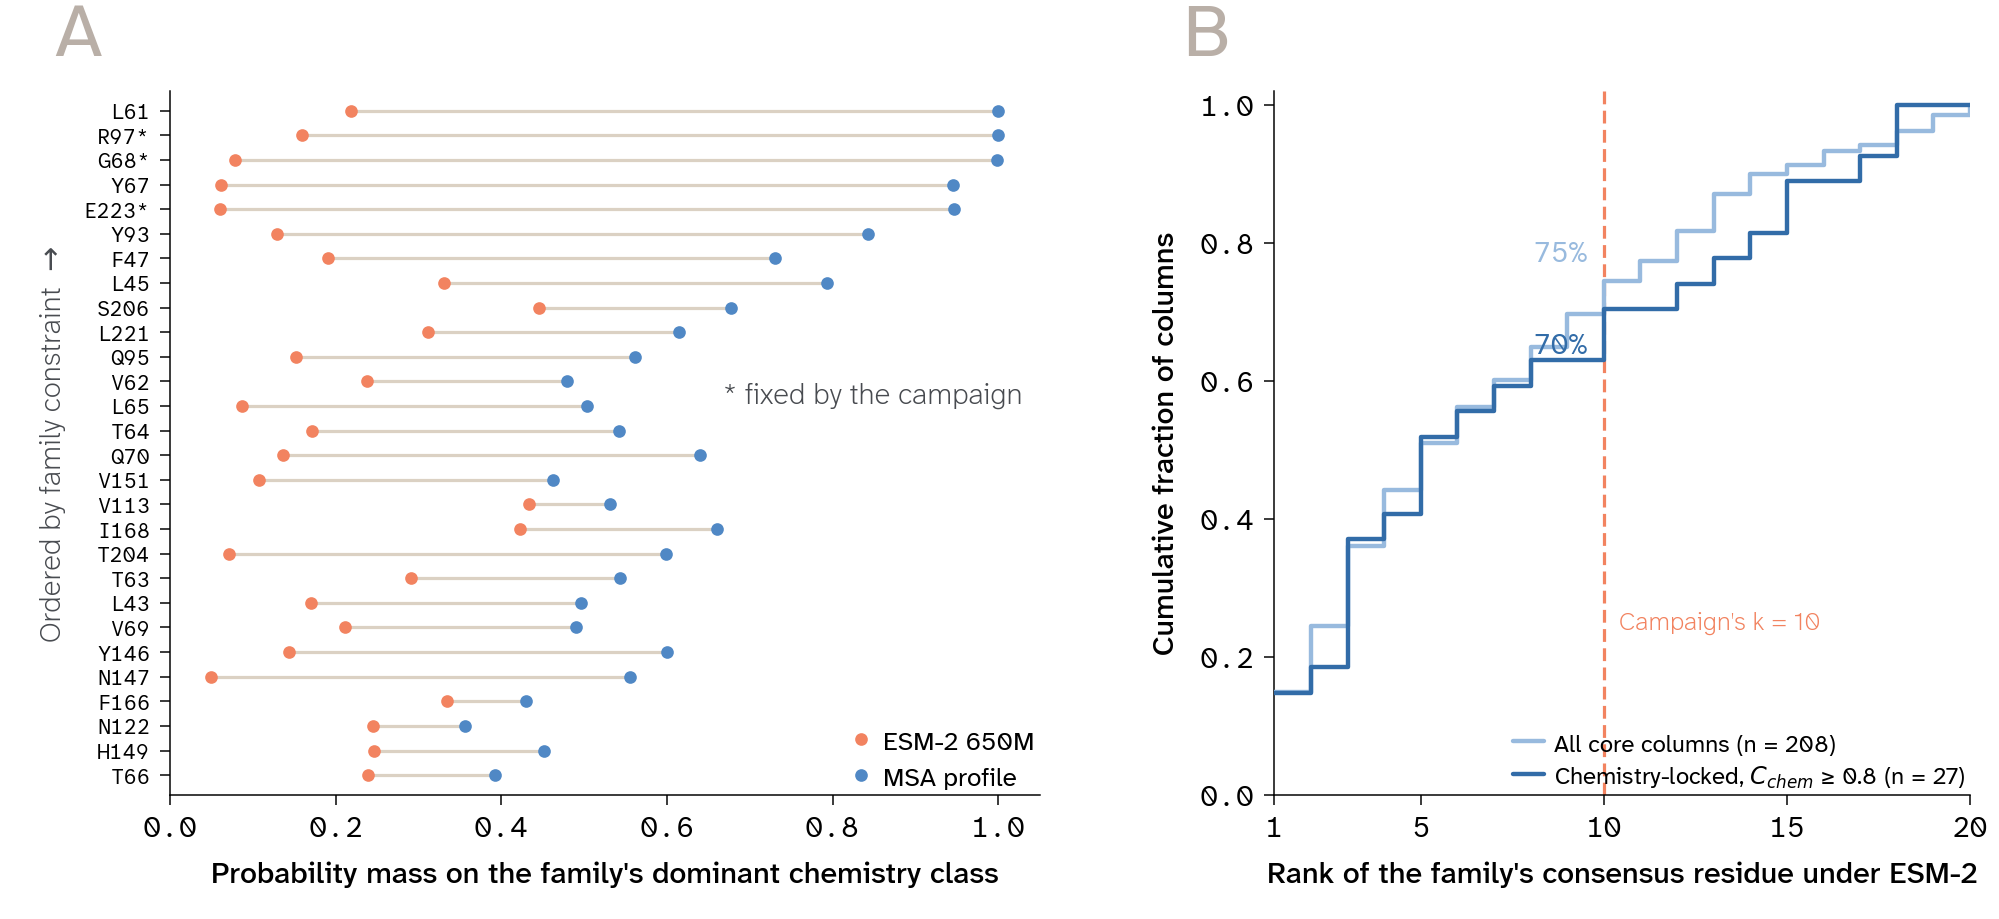

In [10]:
ev = pd.read_csv("results/esm_vs_family_egfp.csv").sort_values("pos_1based")
wc = win.set_index("pos_1based")
ev["C_chem"] = ev.pos_1based.map(wc.C_chem)
ev = ev.sort_values("C_chem").reset_index(drop=True)

fig, (axA, axB) = plt.subplots(1, 2, figsize=(FULL_WIDE * PX, FULL_WIDE * 0.46 * PX),
                               width_ratios=[1.25, 1])
fig.subplots_adjust(left=0.085, right=0.985, bottom=0.135, top=0.90, wspace=0.30)

# --- A: how much mass each distribution puts on the family's own dominant chemistry ----------
y = np.arange(len(ev))
axA.hlines(y, ev.esm_class_mass, ev.fam_class_mass, color=NEUTRAL_SOFT, lw=1.6, zorder=1)
axA.scatter(ev.esm_class_mass, y, s=40, color=C_ESM, linewidths=0, zorder=3, label="ESM-2 650M")
axA.scatter(ev.fam_class_mass, y, s=40, color=C_FAM, linewidths=0, zorder=3, label="MSA profile")
axA.set_yticks(y)
axA.set_yticklabels([f"{r.scaffold_aa}{r.pos_1based}" + ("*" if r.role == "fixed" else "")
                     for r in ev.itertuples()], fontsize=10.5,
                    fontfamily="Atkinson Hyperlegible Mono")
axA.set_ylim(-0.8, len(ev) - 0.2)
axA.set_xlim(0, 1.05)
axA.set_xlabel("Probability mass on the family's dominant chemistry class")
finish(axA, mono="x")
leg = axA.legend(loc="lower right", frameon=False, fontsize=13, handlelength=0.9,
                 labelspacing=0.35, borderpad=0.2)
style_key(leg)
axA.annotate("Ordered by family constraint  →", xy=(-0.135, 0.5), xycoords="axes fraction",
             rotation=90, ha="center", va="center", **ANNOTATION)
axA.annotate("* fixed by the campaign", xy=(0.98, 0.55), xycoords="axes fraction",
             ha="right", va="bottom", **ANNOTATION)
panel_letter(axA, "A", dx=-58)

# --- B: is the family's answer even inside the samplable top-k? ------------------------------
def ecdf(ranks):
    r = np.arange(1, 21)
    return r, np.array([(np.asarray(ranks) <= k).mean() for k in r])

lock = col.C_chem >= 0.80
shades = apc.gradients.blues.to_mpl_cmap().reversed()([0.42, 0.95])
for ranks, c, lab in ((col.fam_top_rank_esm, shades[0], f"All core columns (n = {len(col)})"),
                      (col.fam_top_rank_esm[lock], shades[1],
                       f"Chemistry-locked, $C_{{chem}}$ ≥ 0.8 (n = {int(lock.sum())})")):
    r, y = ecdf(ranks)
    axB.step(r, y, where="post", lw=2.2, color=c, label=lab, zorder=3)
axB.axvline(10, color=C_ESM, lw=1.6, ls=(0, (4, 2)), zorder=2)
axB.set_xlim(1, 20); axB.set_ylim(0, 1.02)
axB.set_xticks([1, 5, 10, 15, 20])
axB.set_xlabel("Rank of the family's consensus residue under ESM-2")
axB.set_ylabel("Cumulative fraction of columns")
finish(axB)
leg = axB.legend(loc="lower right", frameon=False, fontsize=12, handlelength=1.3,
                 labelspacing=0.35, borderpad=0.2)
style_key(leg)
axB.annotate("Campaign's k = 10", xy=(10.4, 0.24), color=C_ESM, fontsize=13,
             fontweight="ultralight")
for ranks, c, dy in ((col.fam_top_rank_esm, shades[0], 10),
                     (col.fam_top_rank_esm[lock], shades[1], -22)):
    v = (np.asarray(ranks) <= 10).mean()
    axB.annotate(f"{v:.0%}", xy=(10, v), xytext=(-8, dy), textcoords="offset points", ha="right",
                 color=c, fontfamily="Atkinson Hyperlegible Mono", fontsize=14.5)
panel_letter(axB, "B")

win_frac = ev.fam_top_in_esm_top10.mean()
print(f"A  mean class mass: family {ev.fam_class_mass.mean():.3f} vs ESM-2 {ev.esm_class_mass.mean():.3f}; "
      f"gap > 0.25 at {(ev.fam_class_mass - ev.esm_class_mass > 0.25).sum()}/{len(ev)} window positions")
print(f"   gap vs family constraint: Spearman ρ = "
      f"{spearmanr(ev.C_chem, ev.fam_class_mass - ev.esm_class_mass).statistic:+.2f}")
print(f"   top-1 agreement in the window: {int(ev.top1_agree.sum())}/{len(ev)}; "
      f"mean Spearman(family, ESM-2) {ev.spearman_fam_esm.mean():+.3f}")
print(f"B  family consensus inside ESM-2's top-10: all columns "
      f"{(col.fam_top_rank_esm <= 10).mean():.0%} (median rank {col.fam_top_rank_esm.median():.0f}), "
      f"chemistry-locked {(col.fam_top_rank_esm[lock] <= 10).mean():.0%} "
      f"(median rank {col.fam_top_rank_esm[lock].median():.0f}), EGFP window {win_frac:.0%}")
save(fig, "esm_vs_msa_design_window")
plt.show()

**Figure 7. The consequence inside the EGFP design window.**
**(A)** For each of the 28 window positions (3 fixed, starred), the probability mass each
distribution places on the chemistry class the family prefers there, ordered bottom-to-top by
family constraint. Averaged over the window the family commits 0.64 of its mass to one class and
ESM-2 commits 0.21 — and the gap widens with constraint, so the positions where the family has the
most to say are the ones ESM-2 is most nearly uniform on.
**(B)** Cumulative distribution of the rank the family's consensus residue takes under ESM-2, over
all 208 core columns and over the 27 chemistry-locked ones, with the campaign's `k = 10`
truncation marked. Its median rank is 5. The truncation keeps it at 75% of columns overall and at
**70%** of the chemistry-locked ones (61% across the EGFP window): being certain in the family
buys no protection at all — if anything the reverse.
**Take away:** the ESM-2 term is not neutral here. It supplies little ranking signal on this fold
(Figure 1) and its top-10 support actively removes the residues the family says belong, most often
where the family is most certain. A per-position prior from `window_alphabet_egfp.csv` costs one
lookup and supplies exactly what is missing.

## What follows from this

1. **The two signals are complementary, not redundant.** Every panel here is a different way of
   showing the same thing: family entropy and ESM-2 entropy are uncorrelated across the barrel
   (ρ = +0.05), their divergence rises with family constraint (ρ = +0.69), and only the family
   predicts a held-out FP's own residues (perplexity 4.9 vs 16.0). Adding a family prior to the
   objective does not double-count the ESM-2 term.

2. **Prefer the family prior where the family is decided.** The natural form is the one already
   computed: `results/window_alphabet_egfp.csv` gives, per window position, the smallest residue
   set covering 90% of the weighted family distribution. Using it to *widen* the proposal support
   — union with ESM-2's top-10 rather than replacing it — fixes the truncation loss in Figure 7B
   without discarding whatever ranking signal ESM-2 does carry.

3. **The one hard constraint still missing.** avGFP L60 / EGFP L61 is `C_chem` = 1.00, RSA 0.00,
   and not one of 763 aligned FPs puts a non-aliphatic residue there — while ESM-2's top three at
   that position are Gly, Pro and Asp (Figure 4). It is currently unrestricted in 12 scaffolds.

4. **What this does not say.** ESM-2 being uninformative *on this fold* is not evidence about ESM-2
   generally — the controls in Figures 2 and 6A are the point of including them. Nor does low
   family constraint mean a position is a good place to edit: the family varies the pocket because
   that is how it changes colour, which is the campaign's strategy working, not a warning. The
   comparison is only informative in one direction, and the direction it is informative in is
   *don't propose residues the whole family refuses to use*.